# 🧩 Minería de Datos — Clase 1 Final
## Clustering Jerárquico + DBSCAN + Comparación con KMeans

Este notebook trabaja dos algoritmos de aprendizaje no supervisado:

1. **Clustering jerárquico**
2. **DBSCAN**

Además, se comparan con **KMeans**, que sirve como modelo base.

---

## Objetivo

Comprender diferentes formas de agrupar datos cuando no existe variable objetivo.

En clustering no tenemos `y`; solo tenemos `X`.

La pregunta central es:

> ¿Existen grupos naturales dentro de los datos?

# 1. Comparación conceptual

| Algoritmo | Idea central | Ventaja | Limitación |
|---|---|---|---|
| KMeans | centroides | simple y rápido | exige elegir K |
| Jerárquico | árbol de agrupamiento | dendrograma | puede ser costoso |
| DBSCAN | densidad | detecta ruido | sensible a eps |

---

## Diferencia clave

- KMeans busca grupos compactos alrededor de centroides.
- Jerárquico muestra cómo se fusionan los grupos.
- DBSCAN encuentra regiones densas y marca puntos aislados como ruido.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram, linkage

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

# 2. Dataset real: Wine Dataset

Usaremos el dataset de vinos.

Cada fila representa un vino.

Cada columna representa una característica química.

Aunque el dataset trae una clase real, **no la usaremos para entrenar clustering**. Solo la usamos como referencia visual.

In [2]:
wine = load_wine()

X = pd.DataFrame(wine.data, columns=wine.feature_names)
y_real = wine.target

print("Dimensiones:", X.shape)
X.head()

Dimensiones: (178, 13)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


# 3. Exploración inicial

Antes de agrupar, revisamos rangos y escalas.

Los algoritmos basados en distancia son sensibles a variables con magnitudes grandes.

In [3]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


# 4. Escalado

Se usa `StandardScaler` para que todas las variables queden en una escala comparable.

Después del escalado:

- media aproximada 0,
- desviación estándar aproximada 1.

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled_df.describe().T[["mean", "std"]]

,mean,std
alcohol,7.943708e-15,1.002821
malic_acid,3.592632e-16,1.002821
ash,-4.066660e-15,1.002821
alcalinity_of_ash,-7.983626e-17,1.002821
magnesium,-7.983626e-17,1.002821
total_phenols,-3.991813e-17,1.002821
flavanoids,9.979533e-16,1.002821
nonflavanoid_phenols,-5.588538e-16,1.002821
proanthocyanins,-1.656602e-15,1.002821
color_intensity,-3.442939e-16,1.002821


# 5. PCA para visualización

Como el dataset tiene muchas variables, usamos PCA para visualizar en 2D.

PCA no entrena el clustering; solo ayuda a representar los datos en dos dimensiones.

In [5]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Dimensiones originales:", X_scaled.shape)
print("Dimensiones PCA:", X_pca.shape)
print("Varianza acumulada:", pca.explained_variance_ratio_.sum())

Dimensiones originales: (178, 13)
Dimensiones PCA: (178, 2)
Varianza acumulada: 0.5540633835693526


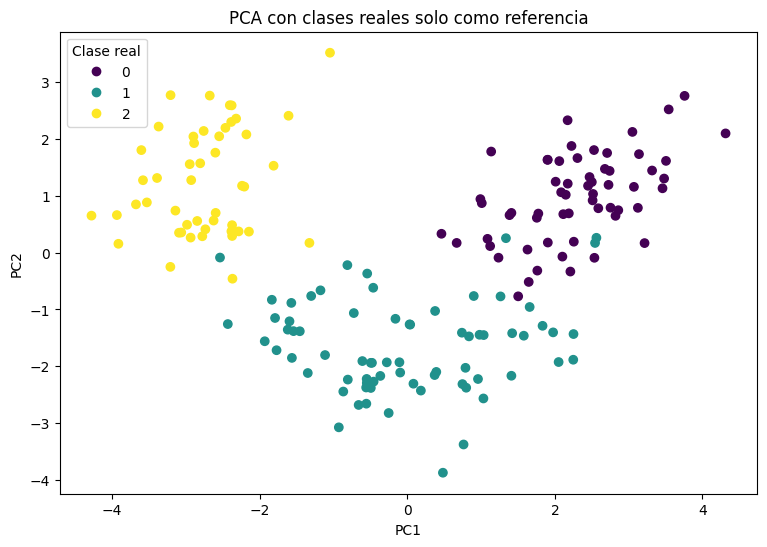

In [6]:
plt.figure(figsize=(9,6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=y_real)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA con clases reales solo como referencia")
plt.legend(*scatter.legend_elements(), title="Clase real")
plt.show()

# 6. KMeans como línea base

KMeans requiere indicar el número de clusters.

Aquí usamos K=3 para comparar con otros métodos.

In [7]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters_kmeans = kmeans.fit_predict(X_scaled)

sil_kmeans = silhouette_score(X_scaled, clusters_kmeans)

print("Silhouette KMeans:", sil_kmeans)

Silhouette KMeans: 0.2848589191898987


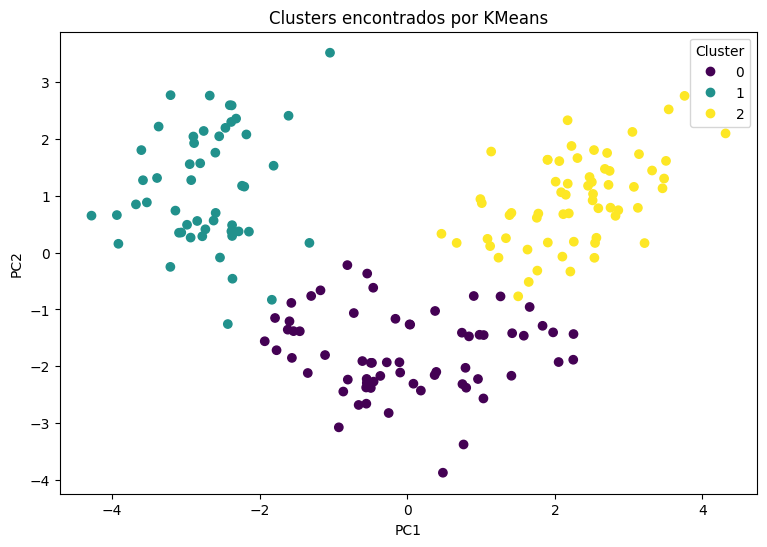

In [8]:
plt.figure(figsize=(9,6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters_kmeans)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Clusters encontrados por KMeans")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.show()

# 7. Método del codo

El método del codo ayuda a decidir cuántos clusters usar.

La inercia mide qué tan cerca están los puntos de sus centroides.

Buscamos un punto donde la reducción de inercia empieza a estabilizarse.

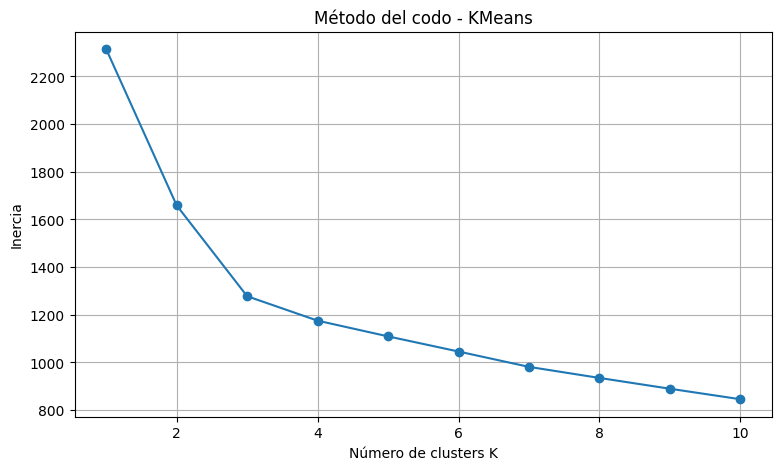

In [9]:
inercias = []
k_values = range(1, 11)

for k in k_values:
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    modelo.fit(X_scaled)
    inercias.append(modelo.inertia_)

plt.figure(figsize=(9,5))
plt.plot(k_values, inercias, marker="o")
plt.xlabel("Número de clusters K")
plt.ylabel("Inercia")
plt.title("Método del codo - KMeans")
plt.grid(True)
plt.show()

# 8. Clustering jerárquico

El clustering jerárquico construye una estructura en forma de árbol.

El enfoque aglomerativo:

1. Empieza con cada observación como un cluster.
2. Va fusionando los clusters más parecidos.
3. Produce un dendrograma.

---

## Linkage

El `linkage` define cómo medir distancia entre grupos.

Usaremos `ward`, que busca clusters compactos.

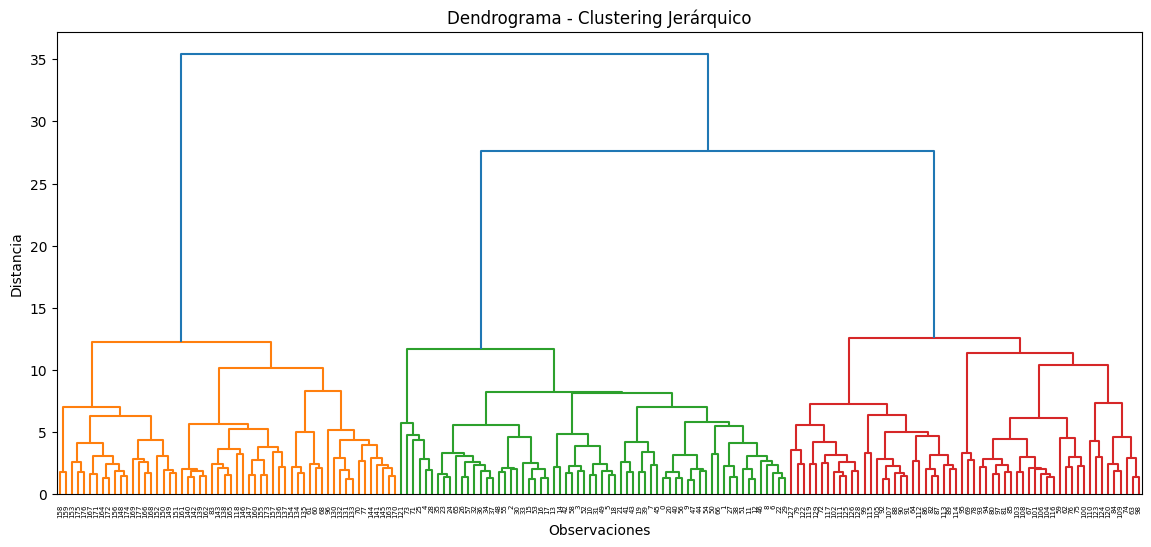

In [10]:
Z = linkage(X_scaled, method="ward")

plt.figure(figsize=(14,6))
dendrogram(Z)
plt.title("Dendrograma - Clustering Jerárquico")
plt.xlabel("Observaciones")
plt.ylabel("Distancia")
plt.show()

# 9. Interpretación del dendrograma

El dendrograma muestra cómo se fusionan los datos.

- Fusiones bajas: observaciones similares.
- Fusiones altas: grupos más diferentes.
- Un corte horizontal permite decidir el número de clusters.

In [11]:
jerarquico = AgglomerativeClustering(n_clusters=3, linkage="ward")

clusters_jerarquico = jerarquico.fit_predict(X_scaled)

sil_jerarquico = silhouette_score(X_scaled, clusters_jerarquico)

print("Silhouette Jerárquico:", sil_jerarquico)

Silhouette Jerárquico: 0.2774439826952266


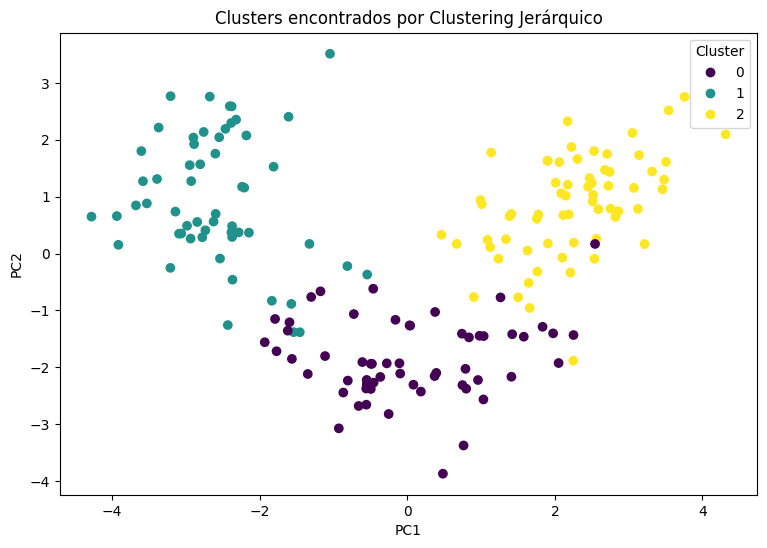

In [12]:
plt.figure(figsize=(9,6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters_jerarquico)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Clusters encontrados por Clustering Jerárquico")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.show()

# 10. DBSCAN

DBSCAN es un algoritmo basado en densidad.

No necesita indicar K.

Puede detectar puntos de ruido.

---

## Conceptos

| Concepto | Significado |
|---|---|
| eps | radio de vecindad |
| min_samples | mínimo de vecinos |
| core point | punto central de zona densa |
| border point | punto en borde de cluster |
| noise | punto aislado |

DBSCAN marca ruido con etiqueta `-1`.

In [13]:
dbscan = DBSCAN(eps=2.2, min_samples=5)

clusters_dbscan = dbscan.fit_predict(X_scaled)

np.unique(clusters_dbscan, return_counts=True)

(array([-1,  0,  1]), array([55, 86, 37]))

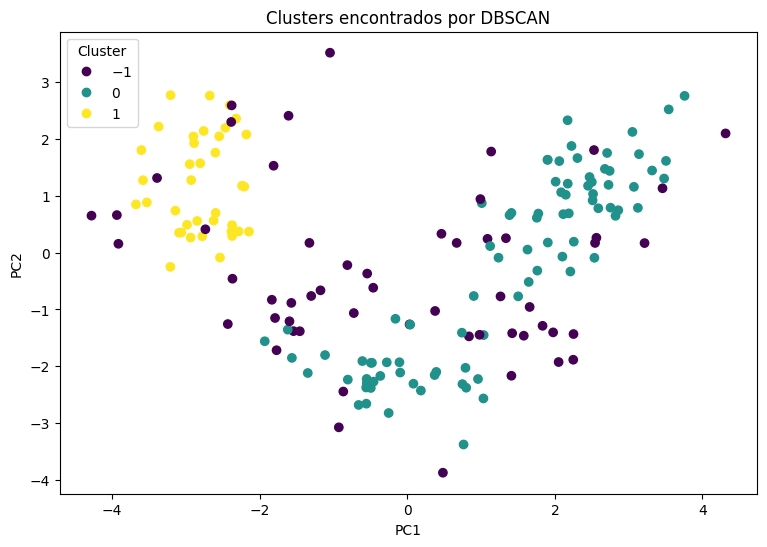

In [14]:
plt.figure(figsize=(9,6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters_dbscan)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Clusters encontrados por DBSCAN")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.show()

# 11. Silhouette para DBSCAN

Silhouette requiere al menos dos clusters válidos.

Si DBSCAN encuentra un solo cluster o todo ruido, no se puede calcular correctamente.

In [15]:
labels_dbscan = clusters_dbscan

n_clusters_dbscan = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)

if n_clusters_dbscan >= 2:
    mask = labels_dbscan != -1
    sil_dbscan = silhouette_score(X_scaled[mask], labels_dbscan[mask])
else:
    sil_dbscan = np.nan

print("Número de clusters DBSCAN:", n_clusters_dbscan)
print("Puntos de ruido:", list(labels_dbscan).count(-1))
print("Silhouette DBSCAN:", sil_dbscan)

Número de clusters DBSCAN: 2
Puntos de ruido: 55
Silhouette DBSCAN: 0.34801201341316823


# 12. Ajuste de eps en DBSCAN

`eps` controla el radio de vecindad.

- eps muy pequeño: muchos puntos quedan como ruido.
- eps muy grande: muchos puntos quedan en un solo cluster.

In [16]:
eps_values = [1.2, 1.5, 1.8, 2.0, 2.2, 2.5, 3.0]

resultados_dbscan = []

for eps in eps_values:
    modelo = DBSCAN(eps=eps, min_samples=5)
    labels = modelo.fit_predict(X_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    if n_clusters >= 2:
        mask = labels != -1
        sil = silhouette_score(X_scaled[mask], labels[mask])
    else:
        sil = np.nan

    resultados_dbscan.append({
        "eps": eps,
        "clusters": n_clusters,
        "ruido": n_noise,
        "silhouette": sil
    })

df_dbscan = pd.DataFrame(resultados_dbscan)
df_dbscan

,eps,clusters,ruido,silhouette
0,1.2,0,178,NaN
1,1.5,0,178,NaN
2,1.8,7,118,0.246187
3,2.0,5,85,0.240461
4,2.2,2,55,0.348012
5,2.5,1,24,NaN
6,3.0,1,11,NaN


# 13. Comparación final

Comparamos:

1. KMeans
2. Clustering jerárquico
3. DBSCAN

In [17]:
comparacion = pd.DataFrame([
    {
        "modelo": "KMeans",
        "clusters": len(set(clusters_kmeans)),
        "ruido": 0,
        "silhouette": sil_kmeans
    },
    {
        "modelo": "Jerárquico",
        "clusters": len(set(clusters_jerarquico)),
        "ruido": 0,
        "silhouette": sil_jerarquico
    },
    {
        "modelo": "DBSCAN",
        "clusters": n_clusters_dbscan,
        "ruido": list(clusters_dbscan).count(-1),
        "silhouette": sil_dbscan
    }
])

comparacion

,modelo,clusters,ruido,silhouette
0,KMeans,3,0,0.284859
1,Jerárquico,3,0,0.277444
2,DBSCAN,2,55,0.348012


# 14. Interpretación comparativa

## KMeans

Ventajas:

- simple,
- rápido,
- fácil de explicar.

Limitaciones:

- exige elegir K,
- funciona mejor con clusters compactos.

## Jerárquico

Ventajas:

- permite dendrograma,
- ayuda a ver estructura,
- no requiere decidir K al inicio.

Limitaciones:

- puede ser costoso,
- sensible al linkage.

## DBSCAN

Ventajas:

- detecta ruido,
- no requiere K,
- puede encontrar formas irregulares.

Limitaciones:

- sensible a eps,
- puede fallar si las densidades son distintas.

# 15. ¿Cuándo usar cada algoritmo?

| Situación | Algoritmo recomendado |
|---|---|
| Quiero algo simple y rápido | KMeans |
| Quiero ver jerarquía | Jerárquico |
| Quiero detectar ruido/outliers | DBSCAN |
| No sé cuántos grupos hay | Jerárquico o DBSCAN |
| Quiero interpretar centroides | KMeans |
| Hay clusters irregulares | DBSCAN |

# 16. Taller final

## Parte A — Conceptos

1. ¿Qué diferencia hay entre aprendizaje supervisado y no supervisado?
2. ¿Qué problema resuelve clustering?
3. ¿Qué diferencia hay entre KMeans, jerárquico y DBSCAN?
4. ¿Por qué se debe escalar?
5. ¿Por qué cluster no es lo mismo que clase?

---

## Parte B — KMeans

1. Aplique KMeans con K=2, K=3 y K=4.
2. Grafique los clusters.
3. Use método del codo.
4. Calcule silhouette.
5. Justifique el mejor K.

---

## Parte C — Clustering jerárquico

1. Genere dendrograma.
2. Explique cómo se interpreta.
3. Aplique AgglomerativeClustering.
4. Compare con KMeans.

---

## Parte D — DBSCAN

1. Pruebe al menos 4 valores de eps.
2. Reporte número de clusters.
3. Reporte puntos de ruido.
4. Calcule silhouette cuando sea posible.
5. Explique cuál eps es más razonable.

---

## Parte E — Comparación

Construya una tabla comparando:

- algoritmo,
- número de clusters,
- silhouette,
- presencia de ruido,
- ventaja principal,
- limitación principal.

---

## Parte F — Conclusión

Redacte mínimo 10 líneas indicando:

1. Qué algoritmo funcionó mejor.
2. Qué métrica usó.
3. Qué interpretación tienen los clusters.
4. Qué limitaciones encontró.
5. Qué algoritmo recomendaría.

# 17. Rúbrica sugerida

| Criterio | Puntaje |
|---|---:|
| Comprensión conceptual | 0.7 |
| Preparación y escalado | 0.6 |
| KMeans + método del codo | 0.8 |
| Clustering jerárquico + dendrograma | 0.9 |
| DBSCAN + análisis de eps/ruido | 1.0 |
| Comparación de algoritmos | 0.6 |
| Conclusión técnica | 0.4 |
| **Total** | **5.0** |

---

# Cierre

Esta clase completa el bloque central de clustering.

La elección del algoritmo depende de:

- forma de los clusters,
- presencia de ruido,
- necesidad de interpretación,
- número esperado de grupos,
- métrica de evaluación.